# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean())# Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).

* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Users:**
*city* con 11.72%. Se debe dejar como nulos ya que el imputar afectaría el análisis por segmentos.

*churn_date* con 88.35%. Se debe dejar como está, ya que los nulos son válidos y representan los usuarios activos.

**Usage**
*date* con 0.125%. Se deben dejar como nulos estos valores, para no perder la información de los usuarios.

*duration* con 55.19% es nulo cuando el registro es un mensaje de texto → no tiene sentido imputar una duración a algo que no es una llamada ni eliminar ya que se perdería la información.

*length* con 44.74% es nulo cuando el registro es una llamada → no tiene sentido imputar una longitud a algo que no es un mensaje de texto ni eliminar ya que se perdería la información.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[["user_id","age"]].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene 4000 registros, iniciando en 10000 y terminando en 13999. Representa el id de cada usuario único. 
- La columna `age` tiene 4000 registros, tiene una desviación estándar alta ya que hay valores inválidos como -999. La media se ve afectada por estos valores de -999. 

In [13]:
# explorar columnas numéricas de usage
usage[["id","user_id","duration","length"]].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` sirven para identificar cada uno de los registros (llamada o mensaje de texto) y el identificador de cada usuario.
- Las columnas `duration` y `length` tienen outliers con valores por encima del percentil 75%.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` tiene 7 valores únicos, siendo Bogotá el que más veces se repite con 808 registros. Además tiene valores nulos (469) con el sentinel "?"
- La columna `plan` tiene 2 valores únicos, siendo el Básico el que más veces se repite con 2595 registros.

In [15]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene 2 tipos de valores únicos siendo "text" el más frecuente entre los usuarios.


---
✍️ **Comentario**: 
En la columna *age* se encontraron valores inválidos de -999. En este caso, como es una columna crítica para el análisis se debe rellenar con la mediana de las edades. 

En las columnas *duration* y *length* se detectaron outliers. Se debe evaluar el límite superior para identificar si se trata de un error o si es posible. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? Age
- ¿Qué acción tomarías?  Rellenar con la mediana

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce", utc=True)

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce", utc=True)

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, hay información de los años 2022-2024 y 2026. Para este análisis se requiere información hasta el año 2024, por lo que la información del año 2026 no es necesaria.

In [19]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date` hay 39950 registros con año de 2024, hay 50 registros que son datos nulos.

✍️ **Comentario**: En *reg_date* hay 40 registros del año 2026, año sin transcurrir al momento de guardar los datos. En este caso es necesario filtrar para que el análisis sea solo de los años 2022 a 2024.

En *date* 39950 son de 2024, a los 50 registros con año nulo hay que convertirlos a NaN, como se mencionó anteriormente, para no perder información de los usuarios. 

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) Sí, el año 2026
- ¿Qué harías con ellas?
Filtrar el dataset para trabajar con los años del 2022 al 2024.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users["city"]=users["city"].replace('?',pd.NA)

# Verificar cambios
users["city"].head()

0    Medellín
1        <NA>
2        CDMX
3      Bogotá
4         GDL
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year == 2026, "reg_date"] = pd.NaT

# Verificar cambios
users["reg_date"].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).sum()
usage["duration"].isna().groupby(usage["type"]).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).sum()
usage["length"].isna().groupby(usage["type"]).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Evaluando la proporción de nulos en las columnas `duration` y `length`, se observa que ambas columnas si dependen de la columna *type*. Esto debido a que cuando son llamadas, la proporción de nulos en call es 0 y de texto es de 99.9%. Lo contrario para length. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text","is_call","duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text": "cant_mensajes",\
                              "is_call":"cant_llamadas",\
                              "duration":"cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on=['user_id'], how='left')

user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile=user_profile[user_profile["reg_date"].dt.year==2024]
user_profile[["age","cant_mensajes","cant_llamadas","cant_minutos_llamada"]].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,1330.000000,1330.000000,1330.000000,1330.000000
mean,48.414286,5.500000,4.557143,24.126669
std,17.963443,2.382293,2.140329,19.458620
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.332500
50%,48.000000,5.000000,4.000000,20.325000
75%,64.000000,7.000000,6.000000,32.542500
max,79.000000,16.000000,13.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)*100

Basico     65.639098
Premium    34.360902
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

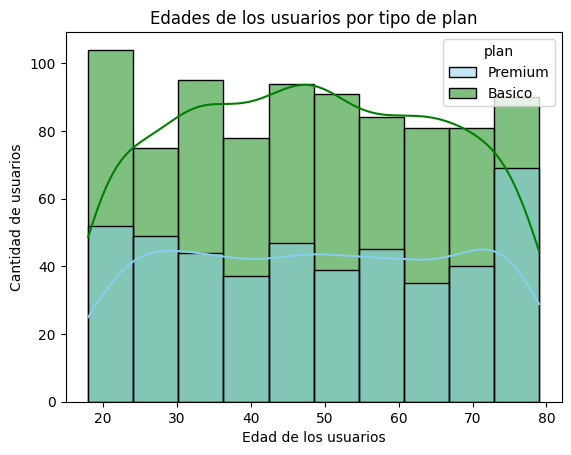

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", bins=10, hue="plan", palette=["skyblue","green"], kde=True)
plt.xlabel("Edad de los usuarios")
plt.ylabel("Cantidad de usuarios")
plt.title("Edades de los usuarios por tipo de plan")
plt.show()

💡Insights: 
- Entre los usuarios de 60+, hay una mayor proporción de plan Básico comparado con otros grupos de edad. Se observa que la distribución es simétrica.

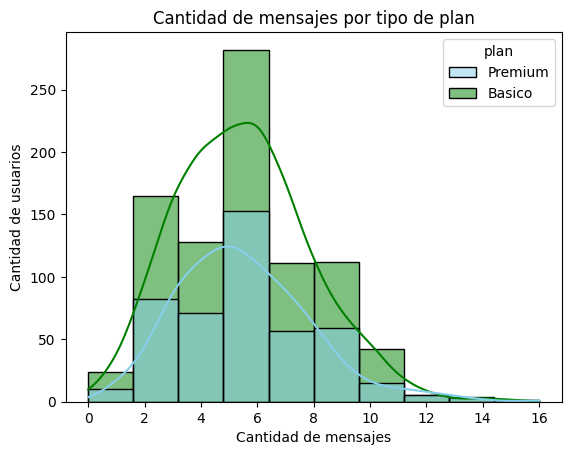

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", bins=10, hue="plan", palette=["skyblue","green"], kde=True)
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.title("Cantidad de mensajes por tipo de plan")
plt.show()

💡Insights: 
- El rango más común para ambos planes es el 5-6 mensajes. Sin embargo, hay mayor proporción en el plan Básico que en el Premium con cantidad de mensajes entre 5-6. Se observan valores cercanos a 0 del lado izquierdo del gráfico y un sesgo a la derecha por valores de hasta 16. 

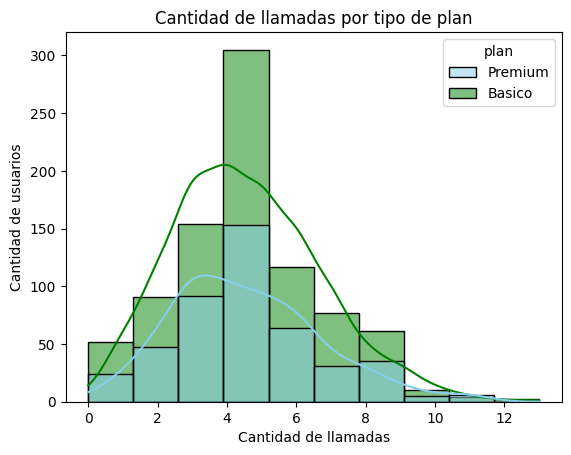

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas", bins=10, hue="plan", palette=["skyblue","green"], kde=True)
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.title("Cantidad de llamadas por tipo de plan")
plt.show()

💡Insights: 
- Para ambos planes el rango más común de cantidad de llamadas es de 4-5. Sin embargo, se observa que hay mayor proporción de cantidad de llamadas en el plan Básico que en el Premium. Hay usuarios de ambos planes que realizan entre 0 o 1 llamada (lado izquierdo) y usuarios que realizan hasta 13 llamadas, teniendo un sesgo a la derecha.

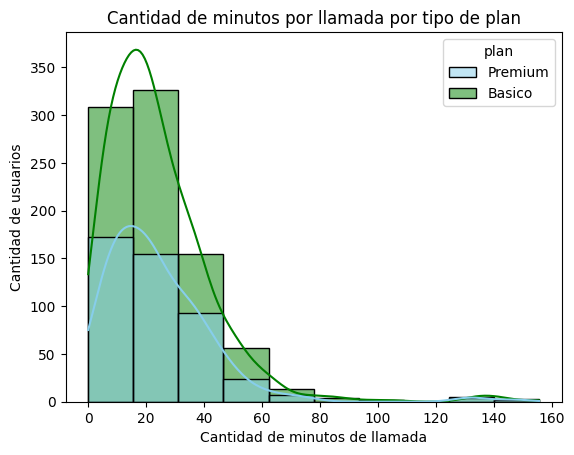

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", bins=10, hue="plan", palette=["skyblue","green"], kde=True)
plt.xlabel("Cantidad de minutos de llamada")
plt.ylabel("Cantidad de usuarios")
plt.title("Cantidad de minutos por llamada por tipo de plan")
plt.show()

💡Insights: 
- Se observa que en ambos planes la mayoría de las llamadas duran entre 0 a 30 minutos. Hay mayor proporción de minutos del plan Básico quedel premium. Hay valores extremos de ambos planes entre 120 y 155, lo cual causa un sesgo a la derecha notorio. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

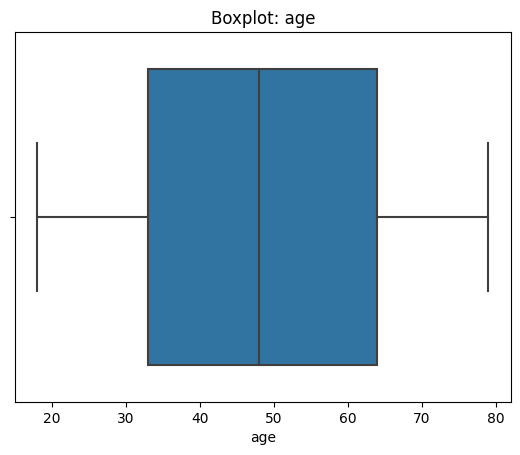

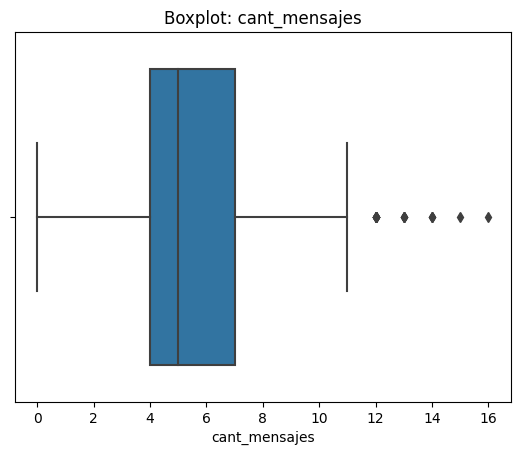

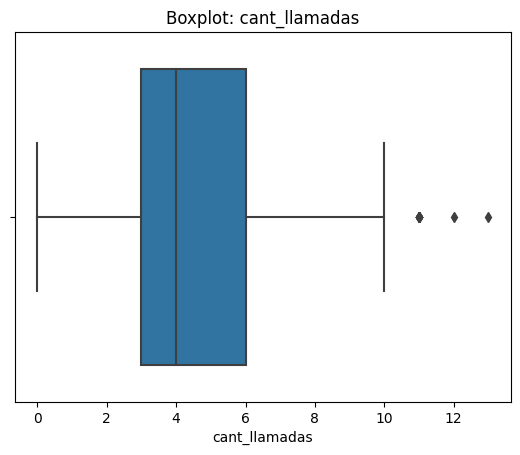

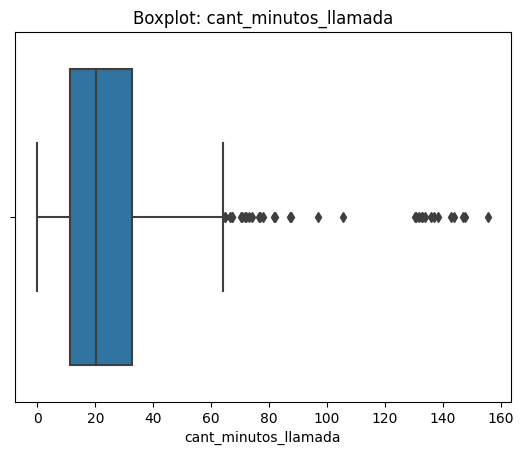

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile,x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: la columna no presenta outliers o valores extremos.
- cant_mensajes: la columna tiene 5 outliers del 12 al 16 del lado derecho. 
- cant_llamadas: la columna tiene 3 outliers del 11 al 13 del lado derecho. 
- cant_minutos_llamada: la columna tiene varios outliers entre 65 y 105 y 130 y 155 del lado derecho.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    print(f'{col} \
    Upper:{upper}')



cant_mensajes     Upper:11.5
cant_llamadas     Upper:10.5
cant_minutos_llamada     Upper:64.35749999999999


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,1330.000000,1330.000000,1330.000000
mean,5.500000,4.557143,24.126669
std,2.382293,2.140329,19.458620
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.332500
50%,5.000000,4.000000,20.325000
75%,7.000000,6.000000,32.542500
max,16.000000,13.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? En este caso se deben mantener los outliers, aunque el límite superior sea 11.5 y el máximo 16, es posible que haya usuarios que tengan arriba de 11 mensajes. 
- cant_llamadas: mantener o no outliers, porqué? En este caso se deben conservar los outliers, aunque el límite superior sea 10.5 y el máximo 13, ya que es posible que haya usuarios con 13 llamadas. 
- cant_minutos_llamada: mantener o no outliers, porqué? En este caso, igualmente se deben mantener los outliers, aunque el límite superior es de 64.35 y el máximo 155.69. Estos son valores extremos, y tienen sentido en el contexto de usuarios que realizan llamadas largas, por ejemplo entre familiares o personas en diferentes ubicaciones. Por lo tanto, no son errores de captura sino comportamientos reales de algunos usuarios.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
def segmentacion_uso(row):
    llamadas=row["cant_llamadas"]
    mensajes=row["cant_mensajes"]

    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"
    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile["grupo_uso"]=user_profile.apply(segmentacion_uso, axis=1)


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
2666,12666,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00+00:00,Premium,NaN,13.0,3.0,11.50,Alto uso
2667,12667,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624+00:00,Premium,NaN,3.0,7.0,33.27,Uso medio
2668,12668,Ana,Torres,21.0,CDMX,2024-01-01 13:08:35.828957240+00:00,Basico,NaN,5.0,7.0,87.56,Uso medio
2669,12669,Sofia,Garcia,58.0,CDMX,2024-01-01 19:42:53.743435864+00:00,Basico,NaN,4.0,5.0,27.62,Uso medio
2670,12670,Ana,Garcia,54.0,MTY,2024-01-02 02:17:11.657914480+00:00,Premium,NaN,9.0,4.0,31.90,Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
def segmentacion_edad (row):
    edad= row["age"]

    if edad < 30:
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile["grupo_edad"]=user_profile.apply(segmentacion_edad, axis=1)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
2666,12666,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00+00:00,Premium,NaN,13.0,3.0,11.50,Alto uso,Joven
2667,12667,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624+00:00,Premium,NaN,3.0,7.0,33.27,Uso medio,Adulto Mayor
2668,12668,Ana,Torres,21.0,CDMX,2024-01-01 13:08:35.828957240+00:00,Basico,NaN,5.0,7.0,87.56,Uso medio,Joven
2669,12669,Sofia,Garcia,58.0,CDMX,2024-01-01 19:42:53.743435864+00:00,Basico,NaN,4.0,5.0,27.62,Uso medio,Adulto
2670,12670,Ana,Garcia,54.0,MTY,2024-01-02 02:17:11.657914480+00:00,Premium,NaN,9.0,4.0,31.90,Uso medio,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

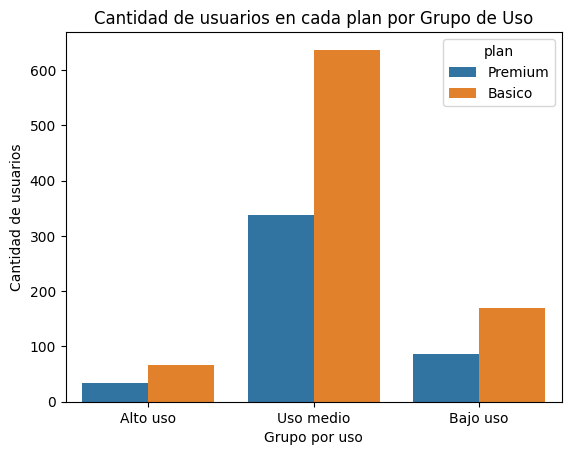

In [41]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso",hue="plan")
plt.xlabel("Grupo por uso")
plt.ylabel("Cantidad de usuarios")
plt.title("Cantidad de usuarios en cada plan por Grupo de Uso")
plt.show()

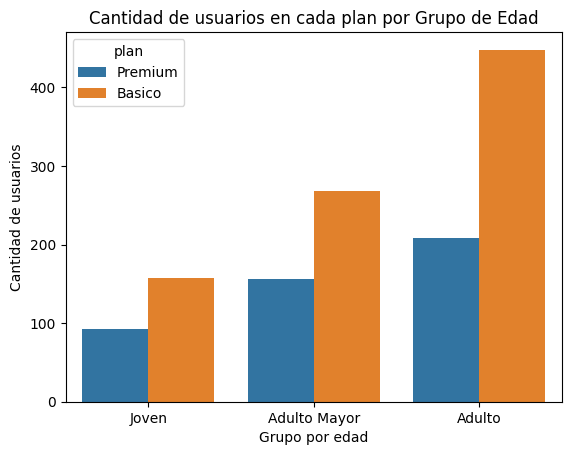

In [42]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad", hue="plan")
plt.xlabel("Grupo por edad")
plt.ylabel("Cantidad de usuarios")
plt.title("Cantidad de usuarios en cada plan por Grupo de Edad")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban? 
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo



⚠️ **Problemas detectados en los datos**
- Se identificaron problemas de calidad en los datos originales como nulos en algunas columnas de los dataframes user y usage. Las columnas con nulos y su porcentaje que representan son: city (11.72%), churn_date (88.35%), date (0.125%), duration (55.19%) y length (44.74%)
- Se identificaron sentinels en la columna *age* como -999 para los usuarios que no se tenía información de la edad, se rellenaron con la mediana de las edades. 
- En la columna *city* se identificaron valores de "?" para algunos registros sin información de ciudad, se dejaron y se trataron como nulos. 
- En las columnas duration y length se encontraron valores extremos, que después fueron identificados como outliers posibles y decidieron conservarse.
- Las columnas de *date* y *reg_date* se convirtieron a formato fecha.
- Se identificó información del año 2026 en los datos originales, un error ya que no había transcurrido ese año y hay información hasta el 2024. Los valores con año 2026, fueron convertidos a NaN y después filtrados para obtener datos hasta el 2024. 

🔍 **Segmentos por Edad**
- Se observa que las personas entre 30 y 59 años, en clasificación de "adultos" son quienes tienen mayores planes con la empresa ConnectaTel, aproximadamente son 650 personas en total. De ellas 440 son del plan básico y solo 210 del plan premium. 
- El segundo mayor grupo con planes en ConnectaTel son los adultos mayores, personas arriba de 60 años. Aproximadamente son 420 usuarios, 260 con plan básico y 160 con plan premium. 
- Los jóvenes, personas menores a 30 años, son el grupo con menor cantidad de planes, ya sea básico o premium en ConnectaTel, solo hay 250 jovenes subscritos, 150 del plan básico y 100 del plan premium. 

📊 **Segmentos por Nivel de Uso**
- La mayoría de los usuarios tienen una catalogación de **uso medio** de sus planes de llamadas y mensajes. Aproximadamente son 970 usuarios que tienen menos de 10 mensajes y llamadas. Dentro de estos usuarios, 630 son del plan básico y 340 del plan premium. 
- Los usuarios catalogados con un uso bajo de su plan no representa ni la mitad de usuarios de uso medio. Para uso bajo son 250 usuarios, 170 con plan básico y solo 80 con plan premium.
- Finalmente, el uso menos utilizado son los de alto uso, con solo 60 usuarios en plan básico y 40 usuarios en plan premium. Es decir, solo 100 usuarios tienen un consumo de alto uso. En el análisis se detectó que hay usuarios con usos extremos, como 155 minutos de llamada y más de 10 llamadas y mensajes. Esto representa que es posible que algunos usuarios requieran de más tiempo en llamada y mayor número de llamadas/mensajes, por ejemplo familiares y amigos que se comunican de diferentes ciudades, grupos de chats de familiares, colegios, trabajos para los adultos. 


➡️ Esto sugiere que el segmento de adultos y el de uso medio, son los segmentos más relevantes para ConnectaTel, ya que son los segmentos donde se concentran la mayoría de los usuarios. 


💡 **Recomendaciones**
- Se recomienda crear un plan más accesible para los usuarios de bajo uso, ya que en su mayoría (170 usuarios) se encuentran en el plan básico y solo ocupan el 5.5% de su capacidad. Esto servirá para atraer y retener a más clientes, ya que tendrían un plan a menor precio y ajustado a su nivel de uso.
- Dado que solo hay 250 jóvenes suscritos a planes y el 60% estan en plan básico, se recomienda aplicar una promoción 2 x 1 en tus primeras 3 mensualidades (mitad de precio para ambos), si obtienes un plan básico  con un amigo en un mes específico. De esta forma se atraerían más clientes jóvenes,  ya que son el sector con menor cantidad de planes en ConnectaTel.
- Se recomienda crear un plan intermedio de básico y premium para los 100 usuarios de alto uso, ya que en casos extremos como de 155 minutos de llamada, tendrían que pagar 5.5 USD  extra, aún así no conviene pagar el plan premium.Esto servirá para atraer  a más clientes, ya que tendrían un plan ajustado a su nivel de uso, ofreciendo mayor límite de mensajes, llamadas y gigas por un precio menor al premium. Igualmente para retener a los 60 usuarios de alto uso actualmente en plan básico, quienes podrían estar pagando cargos adicionales. Al tener mayores opciones de paquetes, los usuarios pueden elegir el que se ajuste a sus necesidades.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`